10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing


=== Aylık Takvim Kontrolü (MS) ===
Aralık: 2019-01-01 .. 2025-07-01  | Beklenen ay sayısı: 79
- Tüm tarihler ay başında.
- Eksik ay YOK, fazladan ay YOK.
- Tekrarlı ay YOK.


10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:53 - cmdstanpy - INFO - Chain [1] done processing
10:48:53 - cmdstanpy - INFO - Chain [1] start processing
10:48:54 - cmdstanpy - INFO - Chain [1] done processing
10:48:54 - cmdstanpy - INFO - Chain [1] start processing
10:48:54 - cmdstanpy - INFO - Chain [1] done processing
10:48:54 - cmdstanpy - INFO - Chain [1] 


=== Hiperparametreler (özet) ===
Prophet: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0}
SARIMA : {'order': (0, 1, 2), 'seasonal_order': (1, 1, 0, 12)}
XGB-direct: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 2.0, 'random_state': 42}
RF-direct : {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2, 'random_state': 42, 'n_jobs': -1}
XGB-residual (Prophet): {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 2.0, 'random_state': 42}
RF-residual  (Prophet): {'n_estimators': 500, 'max_depth': 5, 'min_samples_split': 2, 'random_state': 42, 'n_jobs': -1}
XGB-residual (SARIMA) : {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 1.0, 'random_state': 42}
RF-residual  (SARIMA) : {'n_estimators': 200, 'max_depth': 10, 'min_samples

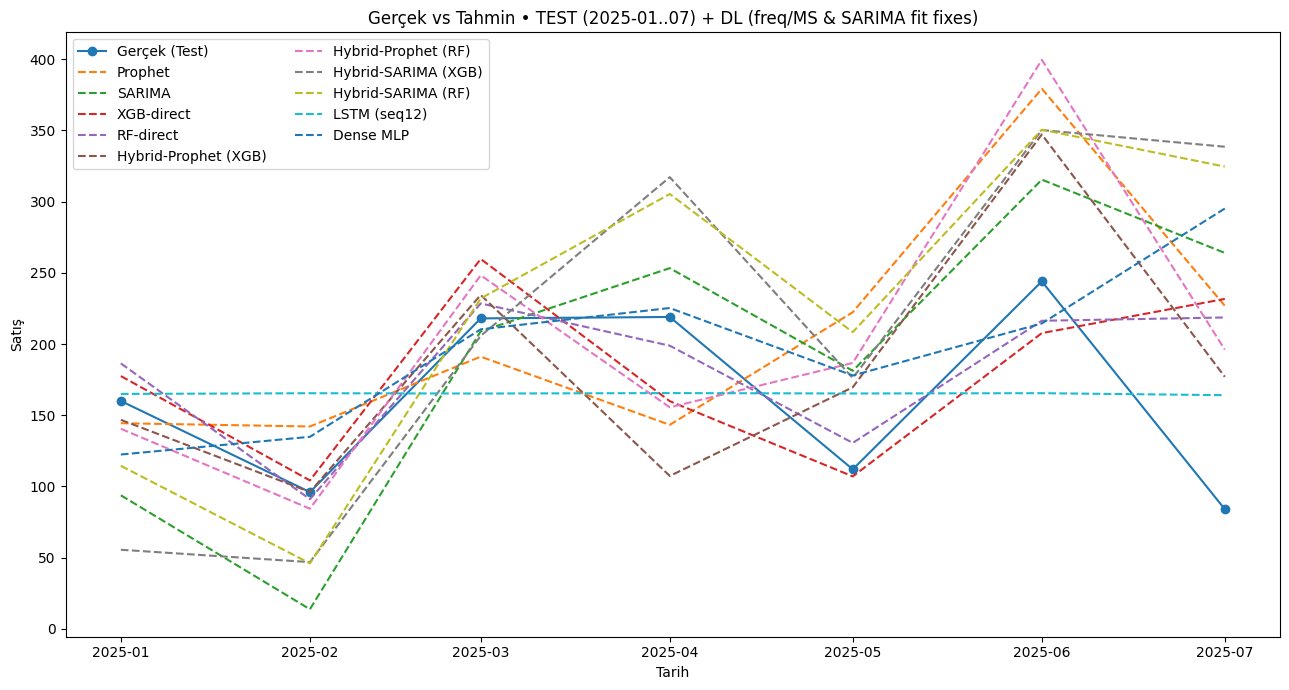

In [4]:
# ==============================================================
# Full Benchmark (FIXED):
# Prophet, SARIMA/SARIMAX, XGBoost-direct, RandomForest-direct,
# Hybrid-Prophet (XGB & RF), Hybrid-SARIMA (XGB & RF),
# Deep Learning: LSTM (seq12) + Dense MLP (tabular)
# ==============================================================

import warnings
warnings.filterwarnings("ignore")  # genel
from warnings import filterwarnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
filterwarnings("ignore", category=ConvergenceWarning)  # raporu sadeleştir

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Deep Learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

TRAIN_END  = pd.Timestamp("2024-12-01")
VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")

RANDOM_STATE = 42
SEQ_LEN = 12  # LSTM sequence length (months)

# ------------------ Utils ------------------
def report_monthly_gaps(df, date_col="ds", set_freq_if_ok=True):
    """
    Aylık (MS) beklenen takvim ile veri tarihlerini karşılaştırır.
    Eksik, fazla ve tekrarlı ayları raporlar.
    Eksik yoksa (ve istenirse) index freq='MS' atanır.
    """
    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' kolonu bulunamadı.")

    d = df[[date_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col).reset_index(drop=True)

    # Ay başında olmayan tarihleri listele
    not_month_start = d.loc[~d[date_col].dt.is_month_start, date_col].tolist()

    # Beklenen ay aralığı (ay başı = MS)
    # (DÜZELTME: to_timestamp('MS') yerine how='start' kullandık)
    start = d[date_col].min().to_period("M").to_timestamp(how="start")
    end   = d[date_col].max().to_period("M").to_timestamp(how="start")
    expected = pd.date_range(start, end, freq="MS")

    # Fiili aylar (ay başına yuvarlayarak)
    actual_ms = d[date_col].dt.to_period("M").dt.to_timestamp(how="start")
    actual_unique = pd.Index(actual_ms.unique()).sort_values()

    # Eksik & fazla aylar
    missing = expected.difference(actual_unique)
    extra   = actual_unique.difference(expected)

    # Tekrarlı aylar
    counts = actual_ms.value_counts().sort_index()
    duplicates = counts[counts > 1]

    # Rapor
    print("=== Aylık Takvim Kontrolü (MS) ===")
    print(f"Aralık: {start.date()} .. {end.date()}  | Beklenen ay sayısı: {len(expected)}")

    if not_month_start:
        print(f"- Ay başı olmayan {len(not_month_start)} tarih var (ilk 5): {[ts.date() for ts in not_month_start[:5]]}")
    else:
        print("- Tüm tarihler ay başında.")

    if len(missing) == 0 and len(extra) == 0:
        print("- Eksik ay YOK, fazladan ay YOK.")
        if len(duplicates) == 0:
            print("- Tekrarlı ay YOK.")
        else:
            print(f"- Tekrarlı ay(lar): {{ {', '.join([f'{k.date()}: {int(v)} kayıt' for k,v in duplicates.items()])} }}")
        # Opsiyonel: freq='MS' ata
        if set_freq_if_ok:
            df_sorted = df.sort_values(date_col).copy()
            df_sorted = df_sorted.set_index(date_col)
            # sadece freq bilgisini set ediyoruz; veri değişmiyor
            df_sorted.index = pd.DatetimeIndex(df_sorted.index, freq="MS")
            return df_sorted.reset_index(), {
                "not_month_start": list(not_month_start),
                "missing": list(missing),
                "extra": list(extra),
                "duplicates": duplicates.to_dict(),
            }
        return df, {
            "not_month_start": list(not_month_start),
            "missing": list(missing),
            "extra": list(extra),
            "duplicates": duplicates.to_dict(),
        }
    else:
        if len(missing) > 0:
            print(f"- Eksik ay sayısı: {len(missing)}")
            print("  Eksik aylar:", [ts.strftime("%Y-%m") for ts in missing])
        if len(extra) > 0:
            print(f"- Aralık dışında {len(extra)} ay var:")
            print("  Fazla aylar:", [ts.strftime("%Y-%m") for ts in extra])
        if len(duplicates) > 0:
            print(f"- Tekrarlı ay(lar): {{ {', '.join([f'{k.strftime('%Y-%m')}: {int(v)} kayıt' for k,v in duplicates.items()])} }}")

        print("\n[Not] Eksikler giderilmeden freq atanmadı.")
        return df, {
            "not_month_start": list(not_month_start),
            "missing": list(missing),
            "extra": list(extra),
            "duplicates": duplicates.to_dict(),
        }


def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def select_x_cols(df_cols):
    preferred = [
        "month","year","quarter",
        "is_Fall","is_Spring","is_Summer","is_Winter",
        "orders","stock","eurtry","usdtry","orders_ratio",
        "y_lag1","y_lag12","orders_lag1","orders_lag12","stock_lag1","stock_lag12",
    ]
    return [c for c in preferred if c in df_cols]

def clean_xy(X: pd.DataFrame, y: pd.Series):
    y_np = y.to_numpy()
    mask_label_ok = np.isfinite(y_np)
    X = X.loc[mask_label_ok]
    y = y.loc[mask_label_ok]
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

def feature_importance_df(model, feature_names, model_name):
    imp = getattr(model, "feature_importances_", None)
    if imp is None:
        return pd.DataFrame(columns=["model","feature","importance"])
    out = pd.DataFrame({"model": model_name, "feature": feature_names, "importance": imp})
    return out.sort_values("importance", ascending=False).reset_index(drop=True)

def ensure_monthly_freq(df):
    """ds kolonu aylık (MS) olacak şekilde freq ata ve boş ay var mı kontrol et."""
    df = df.sort_values("ds").reset_index(drop=True)
    # DatetimeIndex ve MS frekansı
    idx = pd.date_range(df["ds"].min(), df["ds"].max(), freq="MS")
    if len(idx) != len(df) or not (df["ds"].equals(idx)):
        # Eksik ay(lar) var → uyar ve 'asfreq' ile dolduralım
        # Burada sadece exog/dummy'leri ileri dolduruyoruz, y için boş kalırsa uyarı verelim
        print("[UYARI] Aylık dizide eksik ay tespit edildi; asfreq('MS') uygulanıyor.")
        tmp = df.set_index("ds").asfreq("MS")
        # y dışındakileri dolduralım
        for c in tmp.columns:
            if c != "y":
                tmp[c] = tmp[c].interpolate(limit_direction="both").ffill().bfill()
        df = tmp.reset_index().rename(columns={"index":"ds"})
    # freq bilgisini taşıyan DatetimeIndex ile döndür (statsmodels seviyor)
    df = df.set_index("ds")
    df.index.freq = "MS"
    return df.reset_index()

def fit_sarimax_safe(y, order, seasonal_order, exog=None, maxiter=500):
    """SARIMAX fit: lbfgs + fallback"""
    model = SARIMAX(y, order=order, seasonal_order=seasonal_order, exog=exog,
                    enforce_stationarity=False, enforce_invertibility=False)
    try:
        res = model.fit(method="lbfgs", maxiter=maxiter, disp=False)
        return res
    except Exception:
        # fallback: Powell ile biraz daha robust ama yavaş
        res = model.fit(method="powell", maxiter=200, disp=False)
        return res

# ------------------ Load data ------------------
df = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)

# numeric safety
num_cols = ["y","orders","stock","eurtry","usdtry","orders_ratio",
            "y_lag1","y_lag12","orders_lag1","orders_lag12","stock_lag1","stock_lag12"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# >>>>>> FREKANS DÜZELTME (ValueWarning'i çöz) <<<<<<
df = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)

# Eksik/fazla/tekrar kontrolü — hiçbir şeyi otomatik doldurmaz
df, gap_info = report_monthly_gaps(df, date_col="ds", set_freq_if_ok=True)


# splits
mask_train_full = (df["ds"] <= TRAIN_END)
mask_val        = (df["ds"] >= VAL_START) & (df["ds"] <= VAL_END)
mask_train_in   = (df["ds"] <  VAL_START)
mask_test       = (df["ds"] >= TEST_START) & (df["ds"] <= TEST_END)

train_in_df   = df.loc[mask_train_in].copy()
val_df        = df.loc[mask_val].copy()
train_full_df = df.loc[mask_train_full].copy()
test_df       = df.loc[mask_test].copy()

y_test_true   = test_df["y"].to_numpy()
dates_test    = test_df["ds"].to_numpy()

# ------------------ Prophet (opt) ------------------
def optimize_prophet(df_train_in, df_val):
    grid = {
        "changepoint_prior_scale": [0.01, 0.05, 0.1],
        "seasonality_mode": ["additive", "multiplicative"],
        "seasonality_prior_scale": [1.0, 5.0]
    }
    best, best_mae = None, np.inf
    for cps, smode, sps in product(grid["changepoint_prior_scale"], grid["seasonality_mode"], grid["seasonality_prior_scale"]):
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        changepoint_prior_scale=cps, seasonality_mode=smode,
                        seasonality_prior_scale=sps)
            m.fit(df_train_in[["ds","y"]])
            future = m.make_future_dataframe(periods=len(df_val), freq="MS")
            fcst = m.predict(future)[["ds","yhat"]]
            y_pred = fcst[fcst["ds"].isin(df_val["ds"])]["yhat"].to_numpy()
            y_true = df_val["y"].to_numpy()
            mae, _, _ = mae_rmse_mape(y_true, y_pred)
            if mae < best_mae:
                best_mae = mae
                best = {"changepoint_prior_scale":cps, "seasonality_mode":smode, "seasonality_prior_scale":sps}
        except Exception:
            continue
    return best

prophet_best = optimize_prophet(train_in_df, val_df)
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, **prophet_best)
m_prophet.fit(train_full_df[["ds","y"]])
future_full = m_prophet.make_future_dataframe(periods=len(test_df), freq="MS")
fcst_prophet = m_prophet.predict(future_full)[["ds","yhat"]]
prophet_test = fcst_prophet[fcst_prophet["ds"].isin(test_df["ds"])]["yhat"].to_numpy()

# ------------------ SARIMA/SARIMAX (opt) ------------------
exog_cols = [c for c in ["orders","stock","eurtry","usdtry"] if c in df.columns]

# Serileri freq taşıyan index ile hazırlayalım
series_train_in   = train_in_df.set_index("ds")["y"];   series_train_in.index.freq = "MS"
series_val        = val_df.set_index("ds")["y"];        series_val.index.freq = "MS"
series_train_full = train_full_df.set_index("ds")["y"]; series_train_full.index.freq = "MS"

exog_train_in   = train_in_df.set_index("ds")[exog_cols] if exog_cols else None
exog_val        = val_df.set_index("ds")[exog_cols] if exog_cols else None
exog_train_full = train_full_df.set_index("ds")[exog_cols] if exog_cols else None
exog_test       = test_df.set_index("ds")[exog_cols] if exog_cols else None

def optimize_sarima(y_train_in, y_val, exog_train_in=None, exog_val=None):
    pdq_list  = [(p,1,q) for p in [0,1,2] for q in [0,1,2]]
    PDQ_list  = [(P,1,Q,12) for P in [0,1] for Q in [0,1]]
    best, best_mae = None, np.inf
    for order in pdq_list:
        for sorder in PDQ_list:
            try:
                res = fit_sarimax_safe(y_train_in, order, sorder, exog=exog_train_in, maxiter=600)
                fc = res.get_forecast(steps=len(y_val), exog=exog_val).predicted_mean.to_numpy()
                mae, _, _ = mae_rmse_mape(y_val.to_numpy(), fc)
                if mae < best_mae:
                    best_mae = mae
                    best = {"order":order, "seasonal_order":sorder}
            except Exception:
                continue
    return best

sarima_best = optimize_sarima(series_train_in, series_val, exog_train_in, exog_val)
sarima_res = fit_sarimax_safe(series_train_full, sarima_best["order"], sarima_best["seasonal_order"],
                              exog=exog_train_full, maxiter=800)
sarima_test = sarima_res.get_forecast(steps=len(test_df), exog=exog_test).predicted_mean.to_numpy()

# ------------------ XGBoost / RF (direct, opt) ------------------
X_cols = select_x_cols(df.columns)

X_train_in   = train_in_df[X_cols].copy()
y_train_in   = train_in_df["y"].copy()
X_val        = val_df[X_cols].copy()
y_val        = val_df["y"].copy()
X_train_in, y_train_in = clean_xy(X_train_in, y_train_in)
X_val,      y_val      = clean_xy(X_val,      y_val)

X_train_full = train_full_df[X_cols].copy()
y_train_full = train_full_df["y"].copy()
X_train_full, y_train_full = clean_xy(X_train_full, y_train_full)

X_test = test_df[X_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

def optimize_xgb(X_tr_in, y_tr_in, X_v, y_v):
    grid = {
        "n_estimators": [300, 500],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.9],
        "colsample_bytree": [0.9],
        "reg_lambda": [1.0, 2.0]
    }
    best_params, best_mae = None, np.inf
    for n, lr, md, ss, cs, rl in product(grid["n_estimators"], grid["learning_rate"], grid["max_depth"],
                                         grid["subsample"], grid["colsample_bytree"], grid["reg_lambda"]):
        params = dict(n_estimators=n, learning_rate=lr, max_depth=md,
                      subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                      random_state=RANDOM_STATE)
        model = XGBRegressor(**params)
        model.fit(X_tr_in, y_tr_in)
        val_pred = model.predict(X_v)
        mae, _, _ = mae_rmse_mape(y_v, val_pred)
        if mae < best_mae:
            best_mae, best_params = mae, params
    return best_params

def optimize_rf(X_tr_in, y_tr_in, X_v, y_v):
    grid = {
        "n_estimators": [200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }
    best_params, best_mae = None, np.inf
    for n, md, mss in product(grid["n_estimators"], grid["max_depth"], grid["min_samples_split"]):
        params = dict(n_estimators=n, max_depth=md, min_samples_split=mss,
                      random_state=RANDOM_STATE, n_jobs=-1)
        model = RandomForestRegressor(**params)
        model.fit(X_tr_in, y_tr_in)
        val_pred = model.predict(X_v)
        mae, _, _ = mae_rmse_mape(y_v, val_pred)
        if mae < best_mae:
            best_mae, best_params = mae, params
    return best_params

xgb_best = optimize_xgb(X_train_in, y_train_in, X_val, y_val)
xgb_direct = XGBRegressor(**xgb_best)
xgb_direct.fit(X_train_full, y_train_full)
xgb_test = xgb_direct.predict(X_test)

rf_best = optimize_rf(X_train_in, y_train_in, X_val, y_val)
rf_direct = RandomForestRegressor(**rf_best)
rf_direct.fit(X_train_full, y_train_full)
rf_test = rf_direct.predict(X_test)

# ------------------ Hybrid-Prophet (Prophet + Residual XGB/RF) ------------------
m_prophet_tmp = Prophet(yearly_seasonality=True, weekly_seasonality=False, **prophet_best)
m_prophet_tmp.fit(train_in_df[["ds","y"]])
tmp_future = m_prophet_tmp.make_future_dataframe(periods=len(val_df), freq="MS")
tmp_fcst   = m_prophet_tmp.predict(tmp_future)[["ds","yhat"]]

tmp_merged = df.merge(tmp_fcst.rename(columns={"yhat":"yhat_tmp"}), on="ds", how="left")
tr_in = tmp_merged.loc[mask_train_in].copy()
vl    = tmp_merged.loc[mask_val].copy()
tr_in["residual_tmp"] = tr_in["y"] - tr_in["yhat_tmp"]
vl["residual_tmp"]    = vl["y"] - vl["yhat_tmp"]

X_cols_res = select_x_cols(df.columns)
tr_in_nonan = tr_in.dropna(subset=["residual_tmp"]).copy()
vl_nonan    = vl.dropna(subset=["residual_tmp"]).copy()

X_tr_in_res = tr_in_nonan[X_cols_res].copy()
y_tr_in_res = tr_in_nonan["residual_tmp"].copy()
X_val_res   = vl_nonan[X_cols_res].copy()
y_val_res   = vl_nonan["residual_tmp"].copy()

X_tr_in_res, y_tr_in_res = clean_xy(X_tr_in_res, y_tr_in_res)
X_val_res,   y_val_res   = clean_xy(X_val_res,   y_val_res)

xgb_res_best_prophet = optimize_xgb(X_tr_in_res, y_tr_in_res, X_val_res, y_val_res)
xgb_res_prophet = XGBRegressor(**xgb_res_best_prophet)

# Final residual train on TRAIN_FULL
df_with_prophet = df.merge(fcst_prophet.rename(columns={"yhat":"yhat_prophet"}), on="ds", how="left")
train_full_prop = df_with_prophet.loc[mask_train_full].copy()
train_full_prop["residual"] = train_full_prop["y"] - train_full_prop["yhat_prophet"]
tmp_full_nonan = train_full_prop.dropna(subset=["residual"]).copy()

X_tr_full_res = tmp_full_nonan[X_cols_res].copy()
y_tr_full_res = tmp_full_nonan["residual"].copy()
X_tr_full_res, y_tr_full_res = clean_xy(X_tr_full_res, y_tr_full_res)

xgb_res_prophet.fit(X_tr_full_res, y_tr_full_res)
X_test_res = df_with_prophet.loc[mask_test, X_cols_res].copy().replace([np.inf, -np.inf], np.nan).fillna(0)
resid_pred_prophet_xgb = xgb_res_prophet.predict(X_test_res)
hybrid_prophet_xgb_test = prophet_test + resid_pred_prophet_xgb

rf_res_best_prophet = optimize_rf(X_tr_in_res, y_tr_in_res, X_val_res, y_val_res)
rf_res_prophet = RandomForestRegressor(**rf_res_best_prophet)
rf_res_prophet.fit(X_tr_full_res, y_tr_full_res)
resid_pred_prophet_rf = rf_res_prophet.predict(X_test_res)
hybrid_prophet_rf_test = prophet_test + resid_pred_prophet_rf

# ------------------ Hybrid-SARIMA (SARIMA + Residual XGB/RF) ------------------
sarima_in = fit_sarimax_safe(series_train_in, sarima_best["order"], sarima_best["seasonal_order"],
                             exog=exog_train_in, maxiter=600)
fitted_in = sarima_in.fittedvalues
fc_val    = sarima_in.get_forecast(steps=len(val_df), exog=exog_val).predicted_mean

tmp2 = df.copy()
df_in_fit = pd.DataFrame({"ds": series_train_in.index, "yhat_sarima_inval": fitted_in.values})
tmp2 = tmp2.merge(df_in_fit, on="ds", how="left")
tmp2.loc[tmp2["ds"].isin(val_df["ds"]), "yhat_sarima_inval"] = fc_val.to_numpy()

tr_in2 = tmp2.loc[mask_train_in].copy()
vl2    = tmp2.loc[mask_val].copy()
tr_in2["residual_tmp"] = tr_in2["y"] - tr_in2["yhat_sarima_inval"]
vl2["residual_tmp"]    = vl2["y"] - vl2["yhat_sarima_inval"]

tr_in2_nonan = tr_in2.dropna(subset=["residual_tmp"]).copy()
vl2_nonan    = vl2.dropna(subset=["residual_tmp"]).copy()

X_tr_in_res2 = tr_in2_nonan[X_cols_res].copy()
y_tr_in_res2 = tr_in2_nonan["residual_tmp"].copy()
X_val_res2   = vl2_nonan[X_cols_res].copy()
y_val_res2   = vl2_nonan["residual_tmp"].copy()

X_tr_in_res2, y_tr_in_res2 = clean_xy(X_tr_in_res2, y_tr_in_res2)
X_val_res2,   y_val_res2   = clean_xy(X_val_res2,   y_val_res2)

xgb_res_best_sarima = optimize_xgb(X_tr_in_res2, y_tr_in_res2, X_val_res2, y_val_res2)
xgb_res_sarima = XGBRegressor(**xgb_res_best_sarima)

fitted_full_sarima = sarima_res.fittedvalues.reindex(train_full_df.set_index("ds").index)
tmp_full2 = train_full_df.copy()
tmp_full2["yhat_sarima"] = fitted_full_sarima.values
tmp_full2["residual"] = tmp_full2["y"] - tmp_full2["yhat_sarima"]
tmp_full2_nonan = tmp_full2.dropna(subset=["residual"]).copy()

X_tr_full_res2 = tmp_full2_nonan[X_cols_res].copy()
y_tr_full_res2 = tmp_full2_nonan["residual"].copy()
X_tr_full_res2, y_tr_full_res2 = clean_xy(X_tr_full_res2, y_tr_full_res2)

xgb_res_sarima.fit(X_tr_full_res2, y_tr_full_res2)
X_test_res2 = test_df[X_cols_res].copy().replace([np.inf, -np.inf], np.nan).fillna(0)
resid_pred_sarima_xgb = xgb_res_sarima.predict(X_test_res2)
hybrid_sarima_xgb_test = sarima_test + resid_pred_sarima_xgb

rf_res_best_sarima = optimize_rf(X_tr_in_res2, y_tr_in_res2, X_val_res2, y_val_res2)
rf_res_sarima = RandomForestRegressor(**rf_res_best_sarima)
rf_res_sarima.fit(X_tr_full_res2, y_tr_full_res2)
resid_pred_sarima_rf = rf_res_sarima.predict(X_test_res2)
hybrid_sarima_rf_test = sarima_test + resid_pred_sarima_rf

# ------------------ Deep Learning: LSTM (sequence) ------------------
def create_sequences(X, y, ds, seq_len=12):
    Xs, ys, ds_targets = [], [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:(i+seq_len)])
        ys.append(y[i+seq_len])
        ds_targets.append(ds[i+seq_len])
    return np.array(Xs), np.array(ys), np.array(ds_targets)

X_all_tab = df[X_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
y_all = df["y"].to_numpy()
ds_all = df["ds"].to_numpy()
X_seq, y_seq, ds_seq = create_sequences(X_all_tab, y_all, ds_all, SEQ_LEN)

mask_train_dl = ds_seq <  VAL_START
mask_val_dl   = (ds_seq >= VAL_START) & (ds_seq <= VAL_END)
mask_test_dl  = (ds_seq >= TEST_START) & (ds_seq <= TEST_END)

X_tr_seq, y_tr_seq = X_seq[mask_train_dl], y_seq[mask_train_dl]
X_val_seq, y_val_seq = X_seq[mask_val_dl], y_seq[mask_val_dl]
X_te_seq,  y_te_seq  = X_seq[mask_test_dl],  y_seq[mask_test_dl]
ds_te_seq = ds_seq[mask_test_dl]

n_features = X_tr_seq.shape[2]
scalers = [StandardScaler().fit(X_tr_seq[:, :, j]) for j in range(n_features)]
def apply_scalers(X):
    X_out = X.copy()
    for j, sc in enumerate(scalers):
        X_out[:, :, j] = sc.transform(X_out[:, :, j])
    return X_out

X_tr_seq = apply_scalers(X_tr_seq)
X_val_seq = apply_scalers(X_val_seq)
X_te_seq  = apply_scalers(X_te_seq)

def build_lstm(units=32, dropout=0.2, input_shape=None):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

lstm_grid = [(32,0.2), (64,0.2)]
best_lstm, best_val_mae = None, np.inf
for units, dr in lstm_grid:
    lstm = build_lstm(units=units, dropout=dr, input_shape=(SEQ_LEN, n_features))
    es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    rlr= ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10)
    hist = lstm.fit(X_tr_seq, y_tr_seq, validation_data=(X_val_seq, y_val_seq),
                    epochs=200, batch_size=8, callbacks=[es, rlr], verbose=0)
    val_mae = min(hist.history["val_mae"])
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_lstm = lstm

y_pred_lstm = best_lstm.predict(X_te_seq, verbose=0).flatten()
mae_lstm, rmse_lstm, mape_lstm = mae_rmse_mape(y_te_seq, y_pred_lstm)

# ------------------ Deep Learning: Dense MLP (tabular) ------------------
# Not: Pandas append kaldırıldı; doğrudan TRAIN_FULL kullanıyoruz.
X_train_tab = train_full_df.copy()
X_val_tab   = val_df.copy()
X_test_tab  = test_df.copy()

X_tr_mlp = X_train_tab[X_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
y_tr_mlp = X_train_tab["y"].to_numpy()
X_v_mlp  = X_val_tab[X_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
y_v_mlp  = X_val_tab["y"].to_numpy()
X_te_mlp = X_test_tab[X_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
y_te_mlp = X_test_tab["y"].to_numpy()

sc_mlp = StandardScaler().fit(X_tr_mlp)
X_tr_mlp = sc_mlp.transform(X_tr_mlp)
X_v_mlp  = sc_mlp.transform(X_v_mlp)
X_te_mlp = sc_mlp.transform(X_te_mlp)

def build_mlp(width=64, depth=2, dropout=0.2, input_dim=None):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for _ in range(depth):
        model.add(Dense(width, activation="relu"))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

mlp_grid = [(64,2,0.2), (128,2,0.2)]
best_mlp, best_val_mae_mlp = None, np.inf
for w, d, dr in mlp_grid:
    mlp = build_mlp(width=w, depth=d, dropout=dr, input_dim=X_tr_mlp.shape[1])
    es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    rlr= ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10)
    hist = mlp.fit(X_tr_mlp, y_tr_mlp, validation_data=(X_v_mlp, y_v_mlp),
                   epochs=200, batch_size=8, callbacks=[es, rlr], verbose=0)
    val_mae = min(hist.history["val_mae"])
    if val_mae < best_val_mae_mlp:
        best_val_mae_mlp = val_mae
        best_mlp = mlp

y_pred_mlp = best_mlp.predict(X_te_mlp, verbose=0).flatten()
mae_mlp, rmse_mlp, mape_mlp = mae_rmse_mape(y_te_mlp, y_pred_mlp)

# ------------------ Metrics & Report ------------------
rows = []
def add_row(name, y_hat, y_true=y_test_true):
    mae, rmse, mape = mae_rmse_mape(y_true, y_hat)
    rows.append({"Model":name, "MAE":mae, "RMSE":rmse, "MAPE":mape})

add_row("Prophet", prophet_test)
add_row("SARIMA", sarima_test)
add_row("XGB-direct", xgb_test)
add_row("RF-direct", rf_test)
add_row("Hybrid-Prophet (XGB)", hybrid_prophet_xgb_test)
add_row("Hybrid-Prophet (RF)",  hybrid_prophet_rf_test)
add_row("Hybrid-SARIMA (XGB)",  hybrid_sarima_xgb_test)
add_row("Hybrid-SARIMA (RF)",   hybrid_sarima_rf_test)

rows.append({"Model":"LSTM (seq12)", "MAE":mae_lstm, "RMSE":rmse_lstm, "MAPE":mape_lstm})
rows.append({"Model":"Dense MLP",    "MAE":mae_mlp,  "RMSE":rmse_mlp,  "MAPE":mape_mlp})

res_df = pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Hiperparametreler (özet) ===")
print("Prophet:", prophet_best)
print("SARIMA :", sarima_best)
print("XGB-direct:", xgb_best)
print("RF-direct :", rf_best)
print("XGB-residual (Prophet):", xgb_res_best_prophet)
print("RF-residual  (Prophet):", rf_res_best_prophet)
print("XGB-residual (SARIMA) :", xgb_res_best_sarima)
print("RF-residual  (SARIMA) :", rf_res_best_sarima)
print("LSTM grid :", [(32,0.2),(64,0.2)])
print("MLP  grid :", [(64,2,0.2),(128,2,0.2)])

print("\n=== TEST Sonuçları (2025-01..07) + DL ===")
print(res_df)

# ------------------ Feature Importance (Top-10) ------------------
fi_all = []
X_cols_res_full = X_cols

fi_all.append(feature_importance_df(xgb_direct, X_cols_res_full, "XGB-direct"))
fi_all.append(feature_importance_df(rf_direct,  X_cols_res_full, "RF-direct"))
fi_all.append(feature_importance_df(xgb_res_prophet, X_cols_res_full, "Hybrid-Prophet (XGB-res)"))
fi_all.append(feature_importance_df(rf_res_prophet,  X_cols_res_full, "Hybrid-Prophet (RF-res)"))
fi_all.append(feature_importance_df(xgb_res_sarima,  X_cols_res_full, "Hybrid-SARIMA (XGB-res)"))
fi_all.append(feature_importance_df(rf_res_sarima,   X_cols_res_full, "Hybrid-SARIMA (RF-res)"))

fi_all = [f for f in fi_all if not f.empty]
if fi_all:
    fi_df = pd.concat(fi_all, ignore_index=True)
    print("\n=== ÖZELLİK ÖNEMLERİ (Top-10, her model) ===")
    for name in fi_df["model"].unique():
        tmp = fi_df[fi_df["model"] == name].head(10)
        print(f"\n[{name}]")
        print(tmp[["feature","importance"]].to_string(index=False))
else:
    print("\n[Uyarı] Feature importances alınamadı.")

# ------------------ Plot: Actual vs Predictions (TEST) ------------------
plt.figure(figsize=(13,7))
plt.plot(dates_test, y_test_true, "o-", label="Gerçek (Test)")

plt.plot(dates_test, prophet_test, "--", label="Prophet")
plt.plot(dates_test, sarima_test,  "--", label="SARIMA")
plt.plot(dates_test, xgb_test,     "--", label="XGB-direct")
plt.plot(dates_test, rf_test,      "--", label="RF-direct")

plt.plot(dates_test, hybrid_prophet_xgb_test, "--", label="Hybrid-Prophet (XGB)")
plt.plot(dates_test, hybrid_prophet_rf_test,  "--", label="Hybrid-Prophet (RF)")
plt.plot(dates_test, hybrid_sarima_xgb_test,  "--", label="Hybrid-SARIMA (XGB)")
plt.plot(dates_test, hybrid_sarima_rf_test,   "--", label="Hybrid-SARIMA (RF)")

# DL serileri
if len(ds_te_seq) == len(y_pred_lstm):
    plt.plot(ds_te_seq, y_pred_lstm, "--", label="LSTM (seq12)")
plt.plot(dates_test, y_pred_mlp, "--", label="Dense MLP")

plt.title("Gerçek vs Tahmin • TEST (2025-01..07) + DL (freq/MS & SARIMA fit fixes)")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(ncol=2); plt.tight_layout()
plt.show()
